<h1> <center> Netflix Business Analytics Project Report </center> </h1>

In [42]:
#Import required libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#Ignore all incoming warnings (if any):
import warnings
warnings.filterwarnings("ignore")

In [43]:
#Load the dataset:
df = pd.read_csv("netflix_titles.csv")

#### Data inspection + Data preprocessing + Feature Engineering:

In [44]:
#First five rows:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [45]:
#Last 5 rows:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
6229,80000063,TV Show,Red vs. Blue,NaN,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaN,2015,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil..."
6230,70286564,TV Show,Maron,NaN,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaN,2016,TV-MA,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews..."
6231,80116008,Movie,Little Baby Bum: Nursery Rhyme Friends,NaN,NaN,NaN,NaN,2016,NaN,60 min,Movies,Nursery rhymes and original music for children...
6232,70281022,TV Show,A Young Doctor's Notebook and Other Stories,NaN,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaN,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."
6233,70153404,TV Show,Friends,NaN,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaN,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...


In [46]:
#Detailed info:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       6234 non-null   int64 
 1   type          6234 non-null   object
 2   title         6234 non-null   object
 3   director      4265 non-null   object
 4   cast          5664 non-null   object
 5   country       5758 non-null   object
 6   date_added    6223 non-null   object
 7   release_year  6234 non-null   int64 
 8   rating        6224 non-null   object
 9   duration      6234 non-null   object
 10  listed_in     6234 non-null   object
 11  description   6234 non-null   object
dtypes: int64(2), object(10)
memory usage: 584.6+ KB


In [47]:
#Convert 'date_added" attribute to datetime type:
df['date_added'] = df['date_added'].astype(str).str.strip()
df["date_added"] = pd.to_datetime(df["date_added"])

In [48]:
#No. of missing values:
df.isnull().sum()

show_id            0
type               0
title              0
director        1969
cast             570
country          476
date_added        11
release_year       0
rating            10
duration           0
listed_in          0
description        0
dtype: int64

In [49]:
#Data's size:
df.shape

(6234, 12)

In [50]:
# Extract date features:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['day_added'] = df['date_added'].dt.day

# Handle other missing values:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')
df['description'] = df['description'].fillna('No description')

# Duration Feature Engineering:
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
df['duration_unit'] = df['duration'].str.extract('(min|Season)')

# Genre Feature Engineering (Important for Recommendation):
df['genres_list'] = df['listed_in'].str.split(', ')
df['num_genres'] = df['genres_list'].apply(lambda x: len(x) if isinstance(x, list) else 0)




def get_age_group(rating):
    if pd.isna(rating):
        return 'Unknown'
    mature = ['TV-MA', 'R', 'NC-17']
    teen = ['TV-14', 'PG-13']
    family = ['TV-PG', 'PG']
    kids = ['TV-Y', 'TV-Y7', 'G', 'TV-G']
    if rating in mature:
        return 'Mature'
    elif rating in teen:
        return 'Teen'
    elif rating in family:
        return 'Family'
    elif rating in kids:
        return 'Kids'
    return 'General'

df['age_rating_group'] = df['rating'].apply(get_age_group)


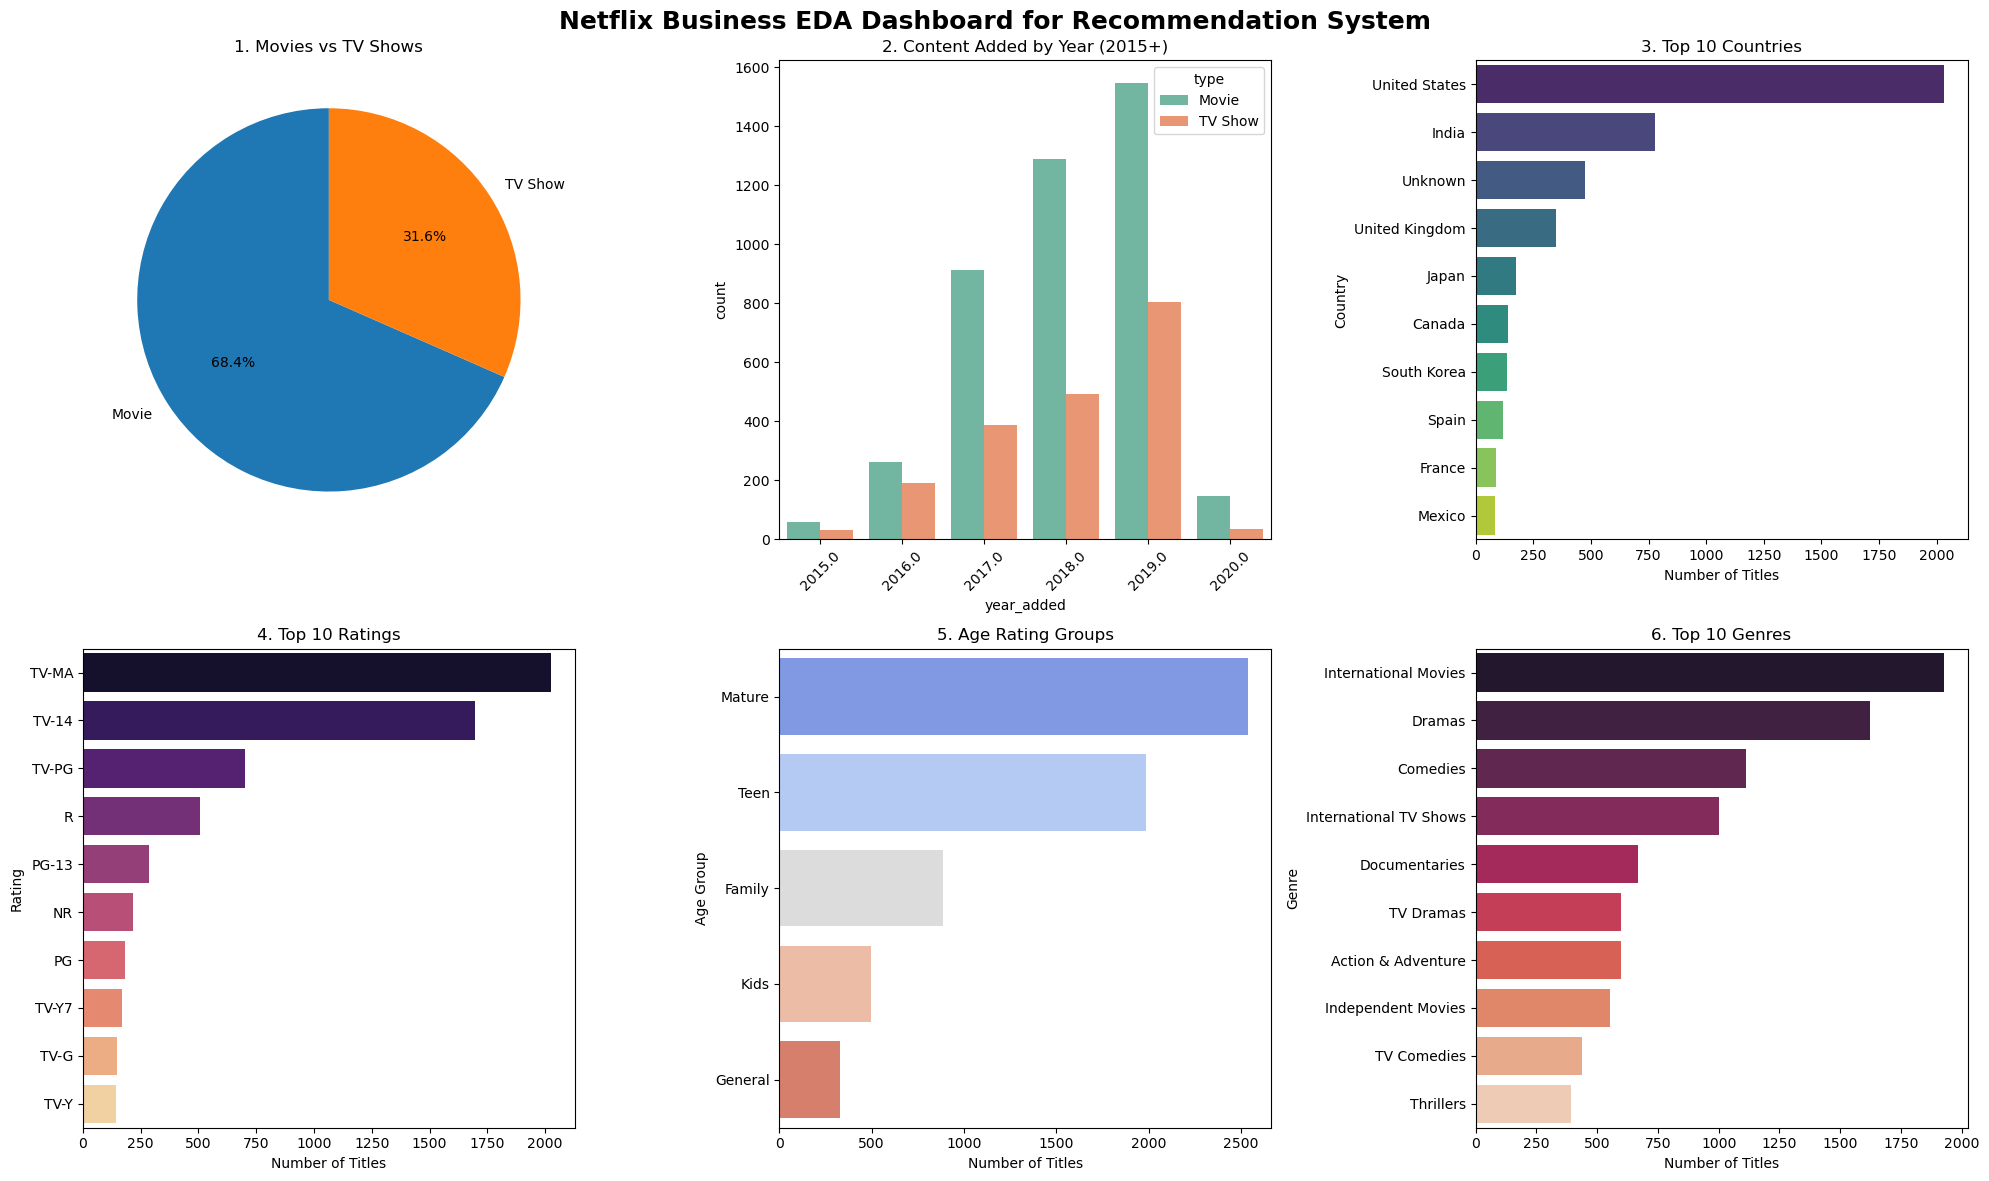

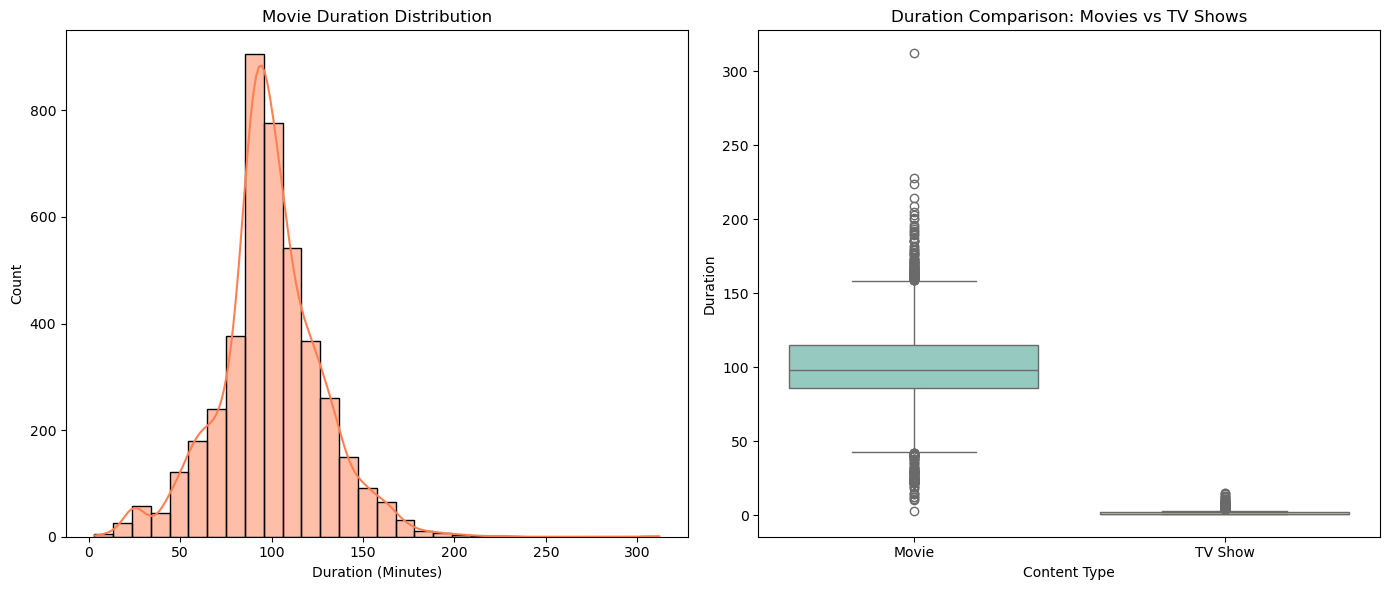

In [51]:


plt.figure(figsize=(20,12))

plt.subplot(2,3,1)
content_type = df['type'].value_counts()

plt.pie(content_type.values,
        labels=content_type.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("1. Movies vs TV Shows")





plt.subplot(2,3,2)

recent = df[df['year_added'] >= 2015]

sns.countplot(data=recent,
              x='year_added',
              hue='type',
              palette='Set2')

plt.title("2. Content Added by Year (2015+)")
plt.xticks(rotation=45)




plt.subplot(2,3,3)

top_countries = df['country'].value_counts().head(10)

sns.barplot(x=top_countries.values,
            y=top_countries.index,
            palette='viridis')

plt.title("3. Top 10 Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")






plt.subplot(2,3,4)

top_ratings = df['rating'].value_counts().head(10)

sns.barplot(x=top_ratings.values,
            y=top_ratings.index,
            palette='magma')

plt.title("4. Top 10 Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")


plt.subplot(2,3,5)

age_group = df['age_rating_group'].value_counts()

sns.barplot(x=age_group.values,
            y=age_group.index,
            palette='coolwarm')

plt.title("5. Age Rating Groups")
plt.xlabel("Number of Titles")
plt.ylabel("Age Group")




plt.subplot(2,3,6)

genres_exploded = df.explode('genres_list')

top_genres = genres_exploded['genres_list'].value_counts().head(10)

sns.barplot(x=top_genres.values,
            y=top_genres.index,
            palette='rocket')

plt.title("6. Top 10 Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.suptitle("Netflix Business EDA Dashboard for Recommendation System",
             fontsize=18,
             fontweight='bold')

plt.tight_layout()

plt.savefig("netflix_business_eda_dashboard.png",
            dpi=300,
            bbox_inches="tight")

plt.show()



plt.figure(figsize=(14,6))
plt.subplot(1,2,1)

sns.histplot(
    df[df['type']=="Movie"]['duration_num'].dropna(),
    bins=30,
    kde=True,
    color='coral'
)

plt.title("Movie Duration Distribution")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Count")

plt.subplot(1,2,2)

sns.boxplot(
    data=df,
    x='type',
    y='duration_num',
    palette='Set3'
)

plt.title("Duration Comparison: Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Duration")

plt.tight_layout()

plt.show()

### Business Report:
- Movies are the dominant category of content.
- From 2017 - 2019 we observed that a lot of new content was added to the content library.
- Most titles belong to the United States.
- TV-MA and TV-14 is dominant rating types.
- Most titles belong to eitheir mature or teen category.
- International Movies , Dramas and Comedies are the dominant genres.
- Most movies have a runtime between 80 and 120 minutes, indicating a preference for standard feature-length content.
- Movies generally have significantly longer durations than TV Shows, while TV Shows are typically limited to a small number of seasons, with only a few long-running series appearing as outliers.

#### Project by:
- Name: Om Satyawan Pathak<br>
- LinkedIn: www.linkedin.com/in/om-satyawan-pathak-029b02368 <br>
- Email: omsatyawanpathakgit@gmail.com (or) omsatyawanpathakwebdevelopment@gmail.com <br>